# Random Forests

This notebook examines Random Forests and demonstrates how to use grid search with cross-validation to find optimal parameters.

Random Forests are ensemble models that combine many decision trees. A single decision tree often has high variance and can be difficult to prune effectively. By averaging predictions or using majority voting across many trees, the ensemble reduces variance without substantially increasing bias.

Random Forests can capture non-linear patterns in the data and tend to ignore unimportant features during splitting. This notebook explores several key parameters that control the structure and complexity of the forest:
- `n_estimators` number of trees in the forest
- `max_depth` how deep the trees will grow
- `min_samples_split` minimum number of samples required to split on internal node
- ` min_samples_leaf` minimum number of samples required to be at the end of leaf node
- `max_features` number of features to consider for each split, options `auto`, `sqrt`, `log2`, `None`, or int

Using `GridSearchCV()` allows evaluation of many parameter combinations and selects the best model based on cross-validation accuracy. When constructing the grid, it is important to consider the size of the dataset and the number of parameter combinations, as large grids can significantly increase computation time.

A variable importance plot is also included to examine which features contribute most to the model.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
# from sklearn.ensemble import RandomForestRegressor # for regression problems
from sklearn.model_selection import GridSearchCV

example = RandomForestClassifier(
    n_estimators=100, # number of trees in the forest
    criterion='gini', # loss function to measure the quality of a split - options: 'gini', 'entropy', 'log_loss'
    max_depth=None, # maximum depth of the tree
    min_samples_split=2, # minimum number of samples required to split an internal node
    min_samples_leaf=1, # minimum number of samples required to be at a leaf node
    min_weight_fraction_leaf=0.0,
    max_features='sqrt', # number of features to consider when looking for the best split - options: 'auto', 'sqrt', 'log2', None, or int/float
    max_leaf_nodes=None, # maximum number of leaf nodes in the tree
    min_impurity_decrease=0.0, # minimum impurity decrease required to split a node
    bootstrap=True, # whether bootstrap samples are used when building trees
    oob_score=False, # whether to use out-of-bag samples to estimate the generalization score
    n_jobs=None, # number of jobs to run in parallel - options: None, int, or -1
    random_state=None, # random seed for reproducibility
    verbose=0, # controls the verbosity when fitting and predicting
    warm_start=False, # whether to reuse the solution of the previous call to fit and add more estimators to the ensemble
    class_weight=None, # weights associated with classes - options: None, 'balanced', 'balanced_subsample', or dict
    ccp_alpha=0.0, # complexity parameter for Minimal Cost-Complexity Pruning
    max_samples=None, # number of samples to draw from X to train each base estimator - options: None, int, or float
    monotonic_cst=None, # monotonic constraints to apply to the tree - options: None, dict, or list of dicts
)

?RandomForestClassifier

In [2]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

In [3]:
splits = np.load("data/iris_splits.npz", allow_pickle=True)

X_sepal_train_std = splits["X_sepal_train_std"]
X_sepal_test_std  = splits["X_sepal_test_std"]
X_petal_train_std = splits["X_petal_train_std"]
X_petal_test_std  = splits["X_petal_test_std"]
X_train_combined = splits["X_train_combined"]
X_test_combined  = splits["X_test_combined"]
y_train = splits["y_train"]
y_test  = splits["y_test"]

Below is the base Random Forest classifier using the default parameters. This model serves as a baseline before applying grid search to tune the hyperparameters.

In [4]:
base_clf = RandomForestClassifier(random_state=42)
base_clf.fit(X_train_combined, y_train)
y_pred = base_clf.predict(X_test_combined)
print("Combined Features Random Forest Classifier")
print(classification_report(y_test, y_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))

Combined Features Random Forest Classifier
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.82      0.90      0.86        10
 Iris-virginica       0.89      0.80      0.84        10

       accuracy                           0.90        30
      macro avg       0.90      0.90      0.90        30
   weighted avg       0.90      0.90      0.90        30

Confusion Matrix:
[[10  0  0]
 [ 0  9  1]
 [ 0  2  8]]
Accuracy: 0.9


In [5]:
parm_grid = {
    'n_estimators': [50, 100, 200, 500], # number of trees
    'max_depth': [None, 2, 5, 10], # maximum depth of the tree
    'min_samples_split': [2, 5, 10], # minimum number of samples required to split an internal node
    'min_samples_leaf': [1, 2, 4], # minimum number of samples required to be at a leaf node
    'max_features': ['sqrt', 'log2', None], # number of features to consider when looking for the best split
}

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=parm_grid, 
    cv=5, 
    n_jobs=-1, 
    verbose=2
)

print("Starting Grid Search...")
grid_search.fit(X_train_combined, y_train)
print("Best Parameters:", grid_search.best_params_)
print("Best Cross-Validation Score:", grid_search.best_score_)


Starting Grid Search...
Fitting 5 folds for each of 432 candidates, totalling 2160 fits
Best Parameters: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 50}
Best Cross-Validation Score: 0.9583333333333334


In [6]:
classifier = RandomForestClassifier(**grid_search.best_params_, random_state=42)
classifier.fit(X_train_combined, y_train)
y_pred = classifier.predict(X_test_combined)
print("Combined Features Random Forest Classifier")
print(classification_report(y_test, y_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))


Combined Features Random Forest Classifier
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      0.90      0.95        10
 Iris-virginica       0.91      1.00      0.95        10

       accuracy                           0.97        30
      macro avg       0.97      0.97      0.97        30
   weighted avg       0.97      0.97      0.97        30

Confusion Matrix:
[[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]
Accuracy: 0.9666666666666667


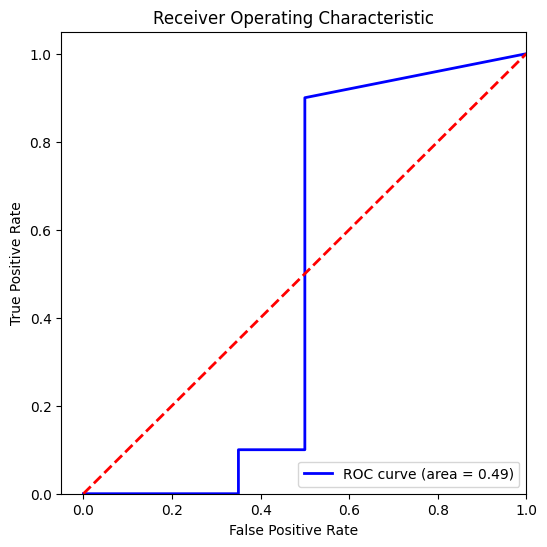

In [7]:
y_test_bin = label_binarize(y_test, classes=classifier.classes_)

fpr, tpr, thresholds = roc_curve(
    y_test_bin[:, 1],  # choose class index
    classifier.predict_proba(X_test_combined)[:, -1]
)

roc_auc = auc(fpr, tpr)
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label='ROC curve (area = {:.2f})'.format(roc_auc))
plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--')
plt.xlim([-0.05, 1.0])   
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

The Random Forest classifier achieved slightly lower performance than the SVM and Logistic Regression models. While the linear models achieved perfect performance with 100% accuracy and an AUC of 1.0, the tuned Random Forest produced an accuracy of 0.966 and an AUC of 0.97 with one misclassification. This marginal difference further supports the observation that the Iris dataset is largely linearly separable when all four features are used.

The default Random Forest model performed noticeably worse, with three misclassifications and an accuracy of approximately 0.90. Applying grid search cross-validation significantly improved the model, illustrating the importance of parameter tuning when using ensemble methods.

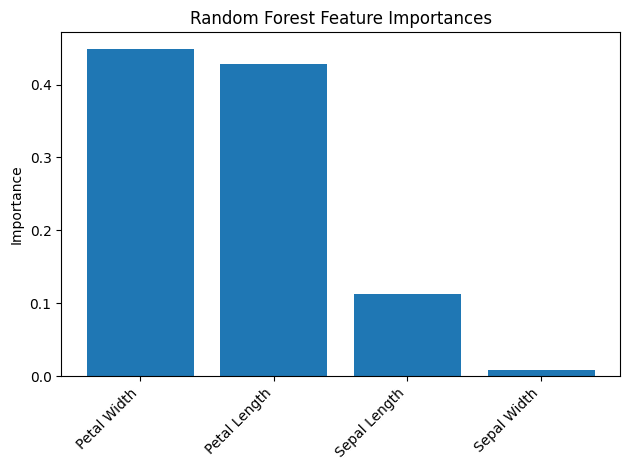

In [8]:
importances = classifier.feature_importances_
idx = np.argsort(importances)[::-1]

plt.bar(range(len(importances)), importances[idx])

feature_names = ["Sepal Length","Sepal Width","Petal Length","Petal Width"] 
plt.xticks(range(len(importances)), np.array(feature_names)[idx], rotation=45, ha="right")

plt.ylabel("Importance")
plt.title("Random Forest Feature Importances")
plt.tight_layout()
plt.show()

Above is the feature importance plot derived from the Random Forest model. The results show that petal width is the most important feature, closely followed by petal length, both with importance values above 0.4. Sepal length contributes modestly with an importance of approximately 0.1, while sepal width has importance near zero and provides little contribution to the model.

This distribution of importance is consistent with earlier observations that petal measurements provide stronger class separation than sepal measurements in the Iris dataset.

In [9]:
def plot_decision_surface(CLF, df, labels, axes, plot_step=1e-1):
    labels = np.asarray(labels).ravel()
    le = LabelEncoder().fit(labels)

    fig, axs = plt.subplots(len(axes), len(axes), figsize=(15, 15))

    color_map = {
    "Iris-setosa": "blue",
    "Iris-versicolor": "yellow",
    "Iris-virginica": "green"
}

    for idx in range(len(axes)):
        for idy in range(len(axes)):
            ax = axs[idx, idy]

            if idx == 0:
                ax.set_ylabel(axes[idy])
            if idy == len(axes) - 1:
                ax.set_xlabel(axes[idx])

            if idx == idy:
                ax.axis("off")
                continue

            x_label, y_label = axes[idx], axes[idy]
            x, y = df[x_label].to_numpy(), df[y_label].to_numpy()

            _clf = CLF()
            _clf.fit(np.column_stack([x, y]), labels)

            xx, yy = np.meshgrid(
                np.arange(x.min() - 1, x.max() + 1, plot_step),
                np.arange(y.min() - 1, y.max() + 1, plot_step),
            )

            Z = _clf.predict(np.c_[xx.ravel(), yy.ravel()])
            Z = le.transform(Z).reshape(xx.shape)

            ax.contourf(xx, yy, Z, cmap=plt.cm.Pastel1, alpha=0.8)

            for lab in le.classes_:
                ax.scatter(
                    x[labels == lab],
                    y[labels == lab],
                    label=str(lab),
                    edgecolor="k",
                    s=20,
                    color=color_map[lab]
                )

    fig.tight_layout(h_pad=0.5, w_pad=0.5, pad=2.5)
    plt.show()

In [10]:
X_train_df = pd.DataFrame(X_train_combined, columns=feature_names)

def clf_factory():
    return RandomForestClassifier(n_estimators=50, random_state=42)

plot_decision_surface(clf_factory, X_train_df, y_train, feature_names)

NameError: name 'pd' is not defined

This figure shows the decision boundaries learned by the Random Forest classifier for all pairwise combinations of the four features. The background colors represent predicted class regions, illustrating the axis-aligned splits typical of decision trees and showing that petal features provide clearer class separation than sepal features.